In [73]:
# Import libraries
import csv
import pandas as pd
import numpy as np

In [74]:
df = pd.read_csv('Dropletdata for datapreprocessing exercise.csv', encoding = 'latin1')

In [75]:
df.head(5)

,Mean droplet size (µm2),Droplet count,Process interval,Category
0,34.597073,1394,0,U
1,37.834522,1294,0,U
2,37.423876,1338,0,U
3,36.133785,1374,0,U
4,31.652493,1566,0,U


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Mean droplet size (µm2)  150 non-null    float64
 1   Droplet count            150 non-null    int64  
 2   Process interval         150 non-null    int64  
 3   Category                 150 non-null    str    
dtypes: float64(1), int64(2), str(1)
memory usage: 4.8 KB


In [77]:
df['Category'].unique()

<StringArray>
['U', 'M', 'A', 'T']
Length: 4, dtype: str

In [78]:
df.head(10)

,Mean droplet size (µm2),Droplet count,Process interval,Category
0,34.597073,1394,0,U
1,37.834522,1294,0,U
2,37.423876,1338,0,U
3,36.133785,1374,0,U
4,31.652493,1566,0,U
5,36.768765,1404,0,U
6,36.517613,1388,0,U
7,35.346197,1379,0,U
8,35.927067,1387,0,U
9,36.529306,1368,0,U


In [79]:
from sklearn import preprocessing

# Z-score standardization
std_scale = preprocessing.StandardScaler().fit(df[['Mean droplet size (µm2)', 'Droplet count']])

df_std = std_scale.transform(df[['Mean droplet size (µm2)', 'Droplet count']])

df_std

array([[ 1.7396491 , -1.44851608],
       [ 2.04983193, -1.50849289],
       [ 2.01048753, -1.4821031 ],
       [ 1.88688283, -1.46051144],
       [ 1.45752631, -1.34535595],
       [ 1.94772078, -1.4425184 ],
       [ 1.9236577 , -1.45211469],
       [ 1.81142333, -1.4575126 ],
       [ 1.86707697, -1.45271446],
       [ 1.92477797, -1.46411005],
       [ 1.43951015, -1.36694761],
       [ 1.4013205 , -1.33276082],
       [ 1.46916732, -1.35675155],
       [ 1.50955254, -1.37174575],
       [ 1.93787141, -1.43292211],
       [ 1.61916807, -1.39993486],
       [ 1.61829793, -1.35975039],
       [ 2.11864282, -1.43352187],
       [ 1.92233342, -1.4425184 ],
       [ 1.90748964, -1.44611701],
       [ 1.36099741, -1.28837798],
       [ 1.71921141, -1.37114599],
       [ 1.85007473, -1.39693602],
       [ 2.18365192, -1.46351028],
       [ 2.11041528, -1.44671677],
       [ 1.70863   , -1.38614019],
       [ 1.57706498, -1.37774344],
       [ 1.50605766, -1.33096152],
       [ 1.60708604,

In [80]:
# Min-Max scaling
minmax_scale = preprocessing.MinMaxScaler().fit(df[['Mean droplet size (µm2)', 'Droplet count']])

df_minmax = minmax_scale.transform(df[['Mean droplet size (µm2)', 'Droplet count']])

df_minmax

array([[0.85784769, 0.01864628],
       [0.95715608, 0.        ],
       [0.94455955, 0.00820436],
       [0.90498616, 0.01491702],
       [0.76752302, 0.05071788],
       [0.92446409, 0.02051091],
       [0.91676003, 0.0175275 ],
       [0.88082698, 0.01584934],
       [0.8986451 , 0.01734104],
       [0.9171187 , 0.01379825],
       [0.76175495, 0.04400522],
       [0.74952812, 0.0546336 ],
       [0.77125001, 0.04717509],
       [0.78417978, 0.04251352],
       [0.92131071, 0.02349431],
       [0.81927438, 0.03374977],
       [0.81899579, 0.04624277],
       [0.97918663, 0.02330785],
       [0.91633605, 0.02051091],
       [0.91158365, 0.01939213],
       [0.73661824, 0.06843185],
       [0.85130434, 0.04269998],
       [0.89320165, 0.03468208],
       [1.        , 0.01398471],
       [0.97655249, 0.01920567],
       [0.84791659, 0.03803841],
       [0.80579462, 0.04064889],
       [0.78306085, 0.05519299],
       [0.81540619, 0.04102182],
       [0.83289027, 0.03449562],
       [0.

In [81]:
from matplotlib import pyplot as plt

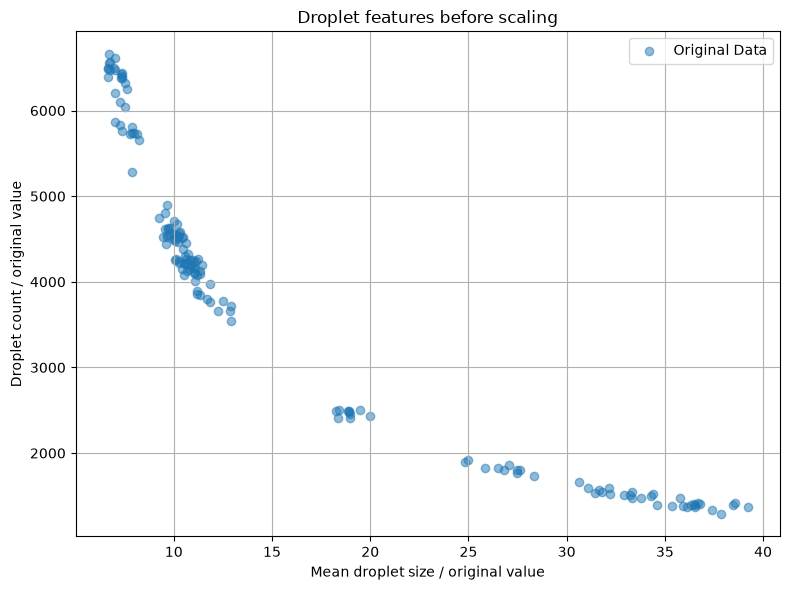

In [82]:
# Plotting data
plt.figure(figsize=(8,6))

# Plotting original data
plt.scatter(df['Mean droplet size (µm2)'], df['Droplet count'], label = 'Original Data', alpha = 0.5)

plt.title('Droplet features before scaling')
plt.xlabel('Mean droplet size / original value')
plt.ylabel('Droplet count / original value')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


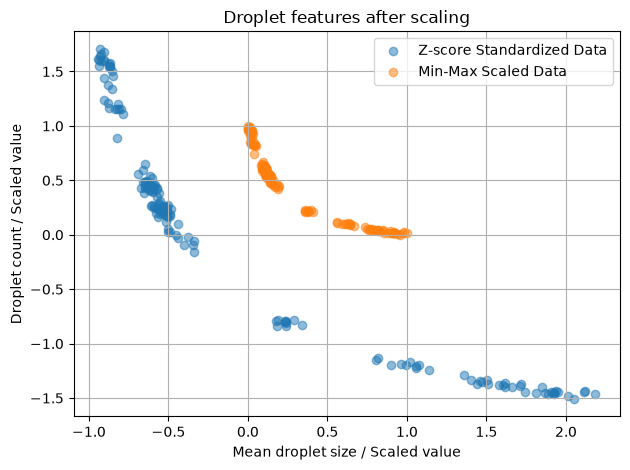

In [83]:
# Plotting Z-score standardized data
plt.scatter(df_std[:, 0], df_std[:, 1], label = 'Z-score Standardized Data', alpha = 0.5)

# Plotting Min-Max scaled data
plt.scatter(df_minmax[:, 0], df_minmax[:, 1], label = 'Min-Max Scaled Data', alpha = 0.5)

plt.title('Droplet features after scaling')
plt.xlabel('Mean droplet size / Scaled value')
plt.ylabel('Droplet count / Scaled value')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

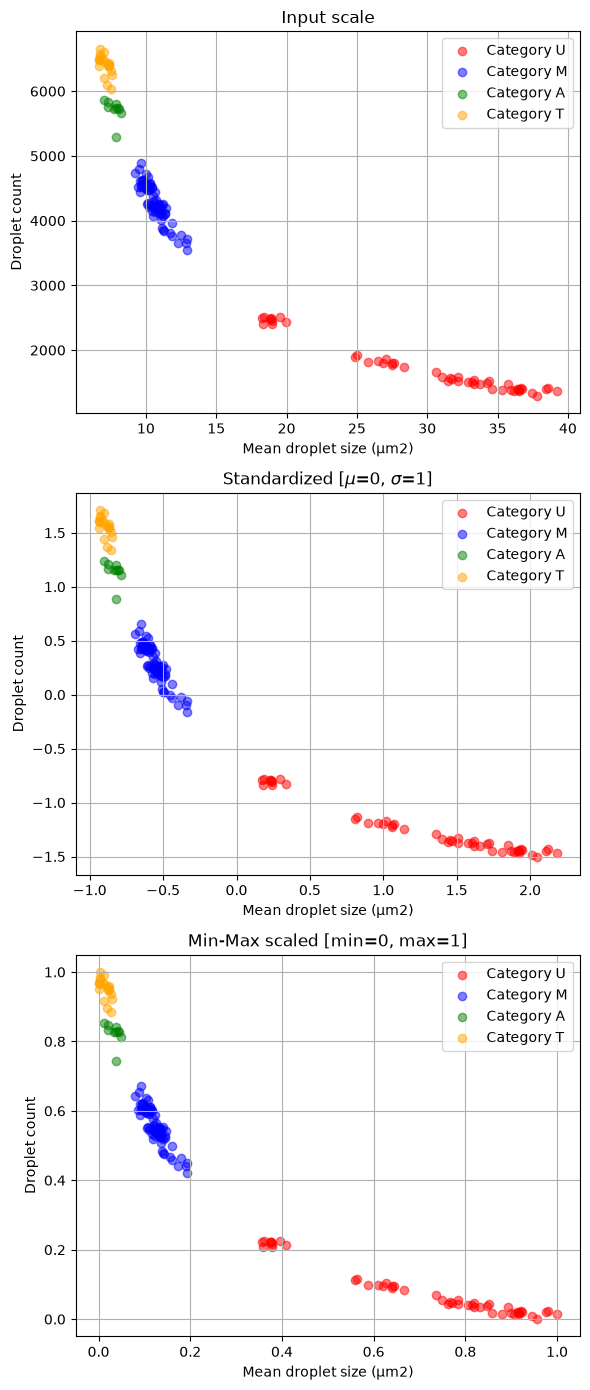

In [86]:
fig, ax = plt.subplots(3, figsize=(6, 14))

for a, d, l in zip(
    range(len(ax)),
    (
        df[['Mean droplet size (µm2)', 'Droplet count']].values,
        df_std,
        df_minmax
    ),
    (
        'Input scale',
        'Standardized [$\\mu$=0, $\\sigma$=1]',
        'Min-Max scaled [min=0, max=1]'
    )
):

    for category, c in zip(
        df['Category'].unique(),
        ('red', 'blue', 'green', 'orange')
    ):

        ax[a].scatter(
            d[df['Category'].values == category, 0],
            d[df['Category'].values == category, 1],
            alpha=0.5,
            color=c,
            label='Category %s' % category
        )

    ax[a].set_title(l)
    ax[a].set_xlabel('Mean droplet size (µm2)')
    ax[a].set_ylabel('Droplet count')
    ax[a].legend(loc='upper right')
    ax[a].grid()

plt.tight_layout()
plt.show()